# 循环

构建agent的时候，需要使用大语言模型，如果没有正是开发，不知道用在哪里，
是不是一个模型需要思考很深，需要用到循环？ 这个大模型在使用agent是网络调用的形式，有问题之后，发给大模型，自己循环思考

和构建agent流程没有关系，agent只看结果，用不到循环，除非奇怪的，一个问题问几遍大模型，（一般没必要，一般可以一次出现很多篇文章即可）

特别说法：ReAct循环结构，针对于大模型，运行过程中，推理思考出，需要调用额外的工具，根据工具返回结果

大模型自身不需要循环
使用场景：比如发消息，天气怎么样，他去搜索11个网页，额外调用工具报错，就要等待再循环访问

1. reason：推理是否要工具
2. action：
3. Observation，
4. Loop：基于新的观察结果继续推理，决定是否继续调用工具，因为结果可能没有调用成功，这个时候，循环去调用工具，称为Agent里面的循环结构

不是大模型没有返回，一般要崩了，后面有专门的异常处理，
工具没办法工作，有Loop循环， 有的大模型还会去找其他工具替代，通过循环形式，不再调用工具，有最终的答案

循环结构有两种方式
1. 静态实现
2. 动态实现



In [2]:
# 下面两个案例，分别实现一下
# 先静态
# 如何判断需要返回output_node

# 动态分支
from typing import TypedDict, Literal
from collections.abc import Sequence

from dotenv import load_dotenv
from langgraph import graph
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langchain.tools import tool

load_dotenv(override=True)
CONTENT_TYPES = ["poem", "ci_poem", "joke"]


model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body= {
        "thinking": {
            "type": "disabled"
        }
    }
)

# 表示通过语言描述来决定什么时候调用工具
# 使用代码函数模拟替代外部API调用的天气查询
@tool(parse_docstring=True)
def get_weather(city: str = "上海"):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city}的天气是晴朗的"

@tool(parse_docstring=True) # 必须按照谷歌文档规范编写注释
def get_news(domain: Literal["AI", "食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    else:
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"


# 要绑定工具到模型
tools = [get_weather, get_news]

model_with_tool = model.bind_tools(tools=tools) # 如何知道大模型

# res = model_with_tool.invoke(input="上海的天气怎么样")
# res = model_with_tool.invoke(input="查询AI新闻")
res = model_with_tool.invoke(input="查询今天上海的天气和AI新闻")
print(res)

content="I'll look up both the weather in Shanghai and the latest AI news for you." additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 341, 'total_tokens': 424, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 128}, 'prompt_cache_hit_tokens': 128, 'prompt_cache_miss_tokens': 213}, 'model_provider': 'deepseek', 'model_name': 'deepseek-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': '1bb62c36-6056-4b8a-82ac-1d531a7d14ba', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--01a08e9f-f9a6-7473-9a1f-18ed0de86bad-0' tool_calls=[{'name': 'get_weather', 'args': {'city': '上海'}, 'id': 'call_00_0MFMWhLHbaSld3edeNF34753', 'type': 'tool_call'}, {'name': 'get_news', 'args': {'domain': 'AI'}, 'id': 'call_01_J8qQJi7rCcNynl7uc1LX8386', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 341, 'output_tokens': 83, 'total_tokens': 424, 'i

这是个很好的问题，涉及 Function Calling 的底层机制。结合你 notebook 里的代码来解释：

## 1. 是的，`bind_tools` 需要后端 LLM 支持

`bind_tools` **本身不做任何"判断"**，它只是在客户端做了一层"格式转换"：

- LangChain 把你的 `@tool` 函数转换成 **JSON Schema 格式**的工具描述
- 然后把它塞进 HTTP 请求的 `tools` 字段，发给 DeepSeek 的 API

真正的"判断"发生在 **DeepSeek 的服务器端**。模型必须经过 **Function Calling（工具调用）专项训练**，才能在合适的时机输出结构化的 `tool_calls`。你的输出里可以看到证据：

```python
'finish_reason': 'tool_calls',   # 模型明确表示：我决定调用工具
tool_calls=[{'name': 'get_weather', 'args': {'city': '上海'}, ...}]
```

如果换成一个不支持 function calling 的模型，API 会直接报错或忽略 `tools` 参数。

## 2. 模型靠什么判断调用哪个工具？

**不是靠函数体内的代码**（模型根本看不到代码），而是靠 `@tool` 装饰器提取出来的三样东西：

| 信息来源 | 你的代码 | 模型看到的内容 |
|---|---|---|
| 函数名 | `get_weather` | `name: "get_weather"` |
| **docstring** | `"查询指定城市当日天气"` | `description` 字段 |
| **类型注解** | `city: str`、`domain: Literal["AI", "食品安全"]` | `parameters` 的 JSON Schema |

所以注释（docstring）**确实是模型判断的核心依据**——这就是为什么你代码里写了 `# 必须按照谷歌文档规范编写注释`。`parse_docstring=True` 会把 Google 风格的 docstring 解析成 `description` 和参数说明。

判断流程本质是一次**语义匹配**：

1. 用户输入 `"查询今天上海的天气和AI新闻"` 发给模型
2. 模型同时看到两个工具的描述：`"查询指定城市当日天气"` 和 `"查询特定领域的当日热点"`
3. 模型在训练中学过"输入意图 ↔ 工具描述"的匹配，于是**并行输出了两个 tool_calls**（你第 3 个 cell 的结果正是如此）
4. 参数也由模型从用户输入中抽取填充：`city="上海"`、`domain="AI"`（`Literal` 注解帮它把取值约束在合法范围内）

## 3. 一个关键认知

整个过程中 **LangChain/LangGraph 只负责"传话"和"执行"**：

```
你的工具定义 ──bind_tools──▶ JSON Schema ──▶ DeepSeek（决策：调哪个、传什么参数）
                                                      │
本地执行 get_weather(city="上海") ◀── tool_calls ◀────┘
```

模型只输出"意图"（工具名+参数 JSON），**真正的函数执行永远发生在你的本地**。这也是为什么你 notebook 最后那个循环结构（`tool_node → llm_node`）才显得必要——模型只负责"决定调什么"，调用失败后把 `ToolMessage` 反馈回去，模型基于新的观察重新推理，这就是 ReAct 循环的本质。

**小结**：`bind_tools` = 把工具说明书（名字+注释+参数类型）翻译成模型能懂的语言发过去；模型是否"会看说明书、会填参数"，取决于后端模型有没有 function calling 能力。

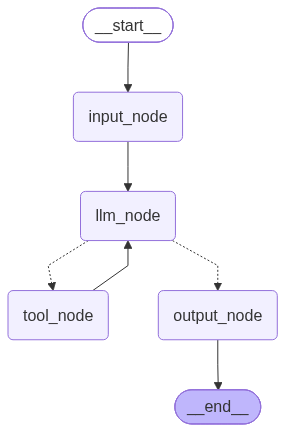

============================== -> ai_res <- ==============================
user_input:  帮我查询杭州当日天气和AI热点
final_output:  好的，查询已全部完成，为您汇总如下：

## 🌤️ 杭州当日天气
**晴朗** ☀️，适合外出活动。

## 🤖 AI 当日热点
**Anthropic 发布了 Claude Opus-4.8**，但有一个有趣的异常现象：
- 通过 API 用中文向它发送"你是谁？"时
- **大多数情况下返回的却是"Qwen"或"Deepseek"**

这条热点挺耐人寻味——一个由 Anthropic 发布的模型，在被中文提问"你是谁"时，却频繁自称为其他厂商的模型（通义千问 Qwen 或深度求索 Deepseek），可能涉及模型训练数据污染、身份认知混淆，或中文语料处理方面的问题，值得关注。

如需进一步了解某条信息的详情，可以告诉我～
================================ System Message ================================

如果工具调用失败，必须重新调用直到成功
================================ Human Message =================================

帮我查询杭州当日天气和AI热点
================================== Ai Message ==================================

我来帮您查询杭州的当日天气和AI热点。
Tool Calls:
  get_weather (call_00_1EGg4E7gq96UAoCwZk7p0386)
 Call ID: call_00_1EGg4E7gq96UAoCwZk7p0386
  Args:
    city: 杭州
  get_news (call_01_OBYFUs3Md0WvXuMzItn68239)
 Call ID: call_01_OBYFUs3Md0WvXuMzItn68239
  Args:
    domain: AI
========================

In [ ]:
from random import randint
from langgraph.graph import MessagesState, StateGraph,START,END
from langchain.messages import SystemMessage, ToolMessage


# 上面绑定工具，下面再来制定循环

# 1. 声明状态
class OverAllState(MessagesState):
    user_input: str
    final_output: str

# 2. 声明节点
# 2.1 输入节点 =》 将用户输入的查询信息 记录到message中，方便后续的大模型调用
def input_node(state: OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])]
    }

# 2.2 llm_node
def llm_node(state: OverAllState) -> OverAllState:
    ai_msg = model_with_tool.invoke(state["messages"]) # 每次带着上次的查询信息回去
    return {
        "messages": [ai_msg]
    }

# 2.3 判断是否需要调用工具
def tool_node(state: OverAllState) -> OverAllState:
    # 判断大模型的返回信息，需要调用tool
    messages = state['messages']

    # 有可能要循环调用，去判断最后一条消息
    ai_msg = messages[-1] # llm节点下来的
    tool_calls = ai_msg.tool_calls

    fail_prob = 6 # 失败的概率80%

    for tool_call in tool_calls:
        if tool_call["name"] == "get_weather":
            # 失败
            if randint(0, 9) < fail_prob: # 某一个id出现了网络波动，要重新调用
                messages.append(ToolMessage(
                    content="网络波动，调用失败，请重试",
                    tool_call_id = tool_call["id"] # 失败了，告诉callid，让模型能知道，下次模型又告诉你要新的id
                ))
            else: # 成功
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            if randint(0, 9) < fail_prob: # 某一个id出现了网络波动，要重新调用
                messages.append(ToolMessage(
                    content="网络波动，调用失败，请重试",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(ToolMessage(
                content="工具名称错误，调用失败，请重试",
                tool_call_id = tool_call["id"]
            ))
    return {
        "messages": messages
    }

# 2.4 返回输出节点
def output_node(state: OverAllState) -> OverAllState:
    return {
        "final_output": state["messages"][-1].content
    }

# 2.5 判断是否需要进行工具节点的调用，还是直接到output节点
def router(state: OverAllState) -> Literal["tool_node", "output_node"]:
    messages = state["messages"]
    last_msg = messages[-1]
    if last_msg.tool_calls:  # 如果上一条需要调用工具， 就走工具
        return "tool_node"
    return "output_node"  # 没有工具，直接走结果

# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("output_node", output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_conditional_edges("llm_node", router)

builder.add_edge("tool_node", "llm_node")   # 不管工具调用怎么样，最后反馈给大预言模型

builder.add_edge("output_node", END)

graph = builder.compile()

display(graph)

ai_res = graph.invoke({
    "user_input": "帮我查询杭州当日天气和AI热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直到成功")]
})
food_safety_res = graph.invoke({
    "user_input": "帮我查询当日天气和食品安全相关的热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直到成功")]
})

# 打印ai
def print_message(msgs):
    print('=' * 30, '-> ai_res <-', '=' * 30)
    print("user_input: ", msgs["user_input"])
    print("final_output: ", msgs["final_output"])
    for msg in msgs["messages"]:
        msg.pretty_print()

print_message(ai_res)
print('8'*30 + '\n\n\n\n\n')
print_message(food_safety_res)


注意tool_node失败后，会拿着自己的信息再次请求大模型  
大模型拿到后，会再次判断，返回新的tool_calls


![image.png](assets/屏幕截图%202026-09-11%20115936.png)

print(123)